## **Happiness scores prediction project 2025 BDA**

# 1. Load and Inspect data

In [14]:
#Load and Inspect Data
import pandas as pd

# Load the dataset
df = pd.read_csv("WHI_Inflation.csv")

# Preview data
print("Top 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values Per Column:")
print(df.isnull().sum().sort_values(ascending=False))


Top 5 Rows:
       Country  Year  Headline Consumer Price Inflation  \
0  Afghanistan  2015                             -0.660   
1  Afghanistan  2016                              4.380   
2  Afghanistan  2017                              4.976   
3  Afghanistan  2018                              0.630   
4  Afghanistan  2019                              2.302   

   Energy Consumer Price Inflation  Food Consumer Price Inflation  \
0                        -4.250000                      -0.840000   
1                         2.070000                       5.670000   
2                         4.440000                       6.940000   
3                         1.474185                      -1.045952   
4                        -2.494359                       3.794770   

   Official Core Consumer Price Inflation  Producer Price Inflation  \
0                                0.219999                       NaN   
1                                5.192760                       NaN   
2    

# 2. Cleaning data

In [15]:
#Clean Missing Data
# Drop columns with too many missing values
columns_to_drop = ['Official Core Consumer Price Inflation', 'Producer Price Inflation']
df.drop(columns=columns_to_drop, inplace=True)

# Impute missing values using median
columns_to_impute = [
    'Headline Consumer Price Inflation',
    'Energy Consumer Price Inflation',
    'Food Consumer Price Inflation',
    'GDP deflator Index growth rate',
    'Perceptions of corruption'
]

for col in columns_to_impute:
    df[col] = df[col].fillna(df[col].median())

# Check if all missing values are handled
print("Remaining missing values:")
print(df.isnull().sum())


Remaining missing values:
Country                              0
Year                                 0
Headline Consumer Price Inflation    0
Energy Consumer Price Inflation      0
Food Consumer Price Inflation        0
GDP deflator Index growth rate       0
Continent/Region                     0
Score                                0
GDP per Capita                       0
Social support                       0
Healthy life expectancy at birth     0
Freedom to make life choices         0
Generosity                           0
Perceptions of corruption            0
dtype: int64


# 3. Get top 10 happiest countries based on score field

In [16]:
# Get top 10 countries based on average happiness score
top_10_countries = df.groupby('Country')['Score'].mean().sort_values(ascending=False).head(10).index.tolist()

# Filter dataset for those countries
df_top10 = df[df['Country'].isin(top_10_countries)]

print("Top 10 happiest countries:")
print(top_10_countries)

Top 10 happiest countries:
['Finland', 'Denmark', 'Iceland', 'Switzerland', 'Norway', 'Netherlands', 'Sweden', 'New Zealand', 'Canada', 'Australia']


In [17]:
df_top10.to_csv("top10_happiest_countries.csv", index=False)

print("Top 10 happiest countries saved to 'top10_happiest_countries.csv'")

Top 10 happiest countries saved to 'top10_happiest_countries.csv'


# 4. Linear Regression Model

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

country_feature_weights = {}
lr_model_scores = {}

# Loop through each country
for country in top_10_countries:
    df_country = df[df['Country'] == country]

    # Define features and target
    X = df_country.drop(columns=['Country', 'Year', 'Continent/Region', 'Score'])
    y = df_country['Score']

    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Train linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Extract feature importances (coefficients)
    feature_weights = dict(zip(X.columns, model.coef_))
    country_feature_weights[country] = feature_weights

    # Evaluate the model
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    lr_model_scores[country] = {
        'R² Score': r2,
        'MAE': mae,
        'RMSE': rmse
    }

print("Linear Regression model trained!")

Linear Regression model trained!


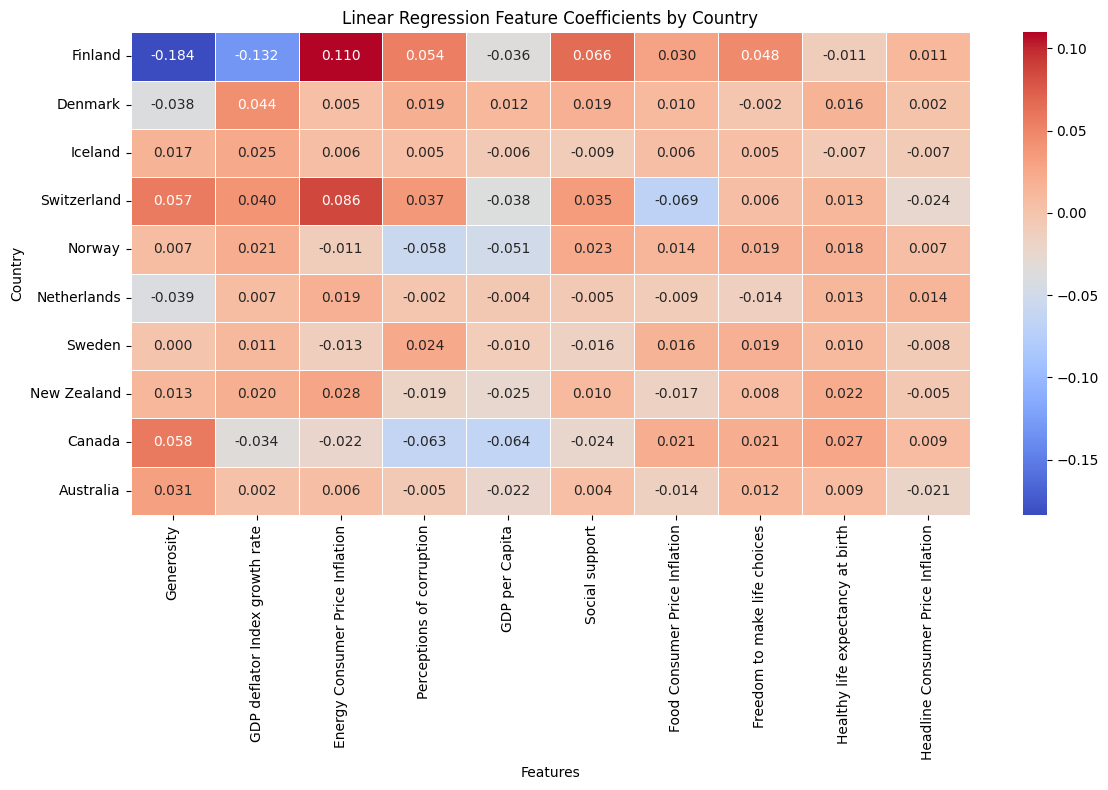

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine all feature weights into a single DataFrame
df_feature_importance = pd.DataFrame(country_feature_weights).T

# Sort features by average absolute importance (optional)
df_feature_importance = df_feature_importance.reindex(
    df_feature_importance.abs().mean().sort_values(ascending=False).index, axis=1
)

# Display the results in heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_feature_importance, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title("Linear Regression Feature Coefficients by Country")
plt.xlabel("Features")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


# 5. Random Forest Model

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf_country_feature_importances = {}
rf_model_scores = {}

for country in top_10_countries:
    df_country = df[df['Country'] == country]

    # Define features and target
    X = df_country.drop(columns=['Country', 'Year', 'Continent/Region', 'Score'])
    y = df_country['Score']

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Train Random Forest
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Store feature importance
    feature_importances = dict(zip(X.columns, rf_model.feature_importances_))
    rf_country_feature_importances[country] = feature_importances

    # Evaluate
    y_pred = rf_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    rf_model_scores[country] = {
        'R² Score': r2,
        'MAE': mae,
        'RMSE': rmse
    }


# Create heatmap-style table of feature importances
df_rf_importance = pd.DataFrame(rf_country_feature_importances).T
df_rf_importance = df_rf_importance.reindex(
    df_rf_importance.mean().sort_values(ascending=False).index, axis=1
)


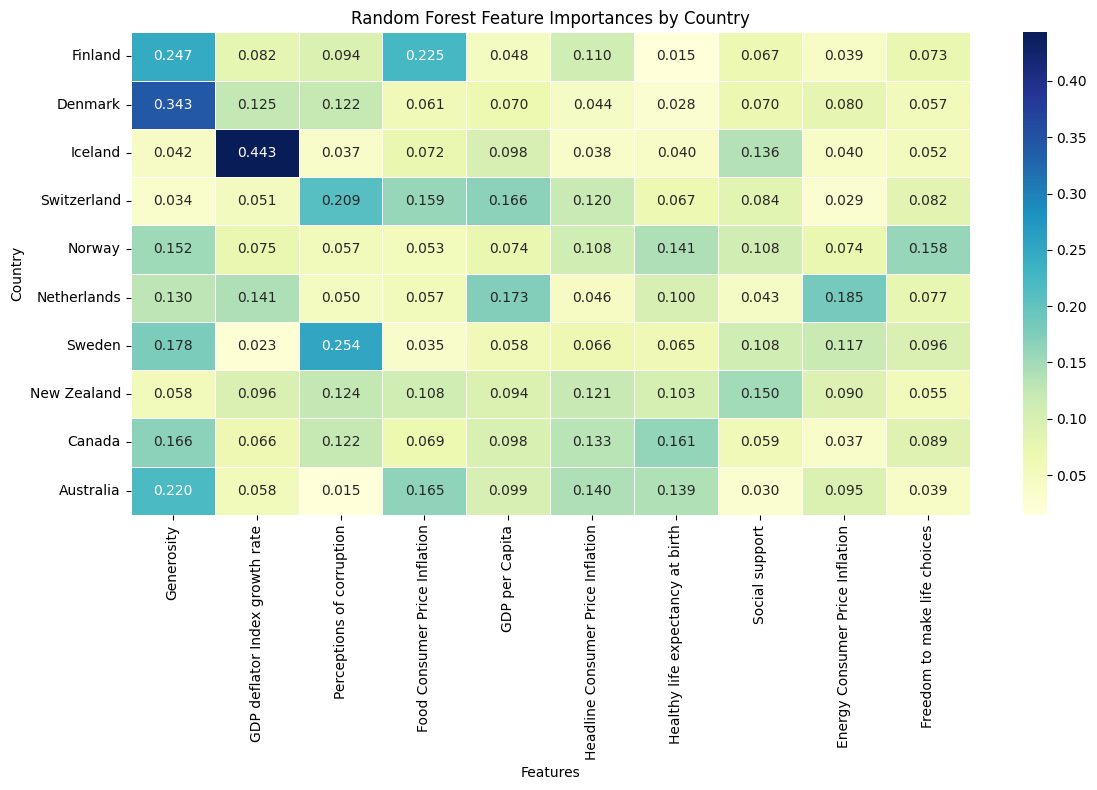

In [21]:
# Heatmap visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df_rf_importance, annot=True, cmap='YlGnBu', linewidths=0.5, fmt=".3f")
plt.title('Random Forest Feature Importances by Country')
plt.xlabel('Features')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# 6. XGBoost Model

In [22]:
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

# Create storage for results
xgb_country_feature_importances = {}
xgb_model_scores = {}

# Loop through top 10 happiest countries
for country in top_10_countries:
    df_country = df[df['Country'] == country]

    # Define features and target
    X = df_country.drop(columns=['Country', 'Year', 'Continent/Region', 'Score'])
    y = df_country['Score']

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # Train XGBoost Regressor
    xgb_model = XGBRegressor(n_estimators=50, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)

    # Store feature importances
    importances = dict(zip(X.columns, xgb_model.feature_importances_))
    xgb_country_feature_importances[country] = importances

    # Evaluate the model
    y_pred = xgb_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    xgb_model_scores[country] = {
        "R² Score": r2,
        "MAE": mae,
        "RMSE": rmse
    }


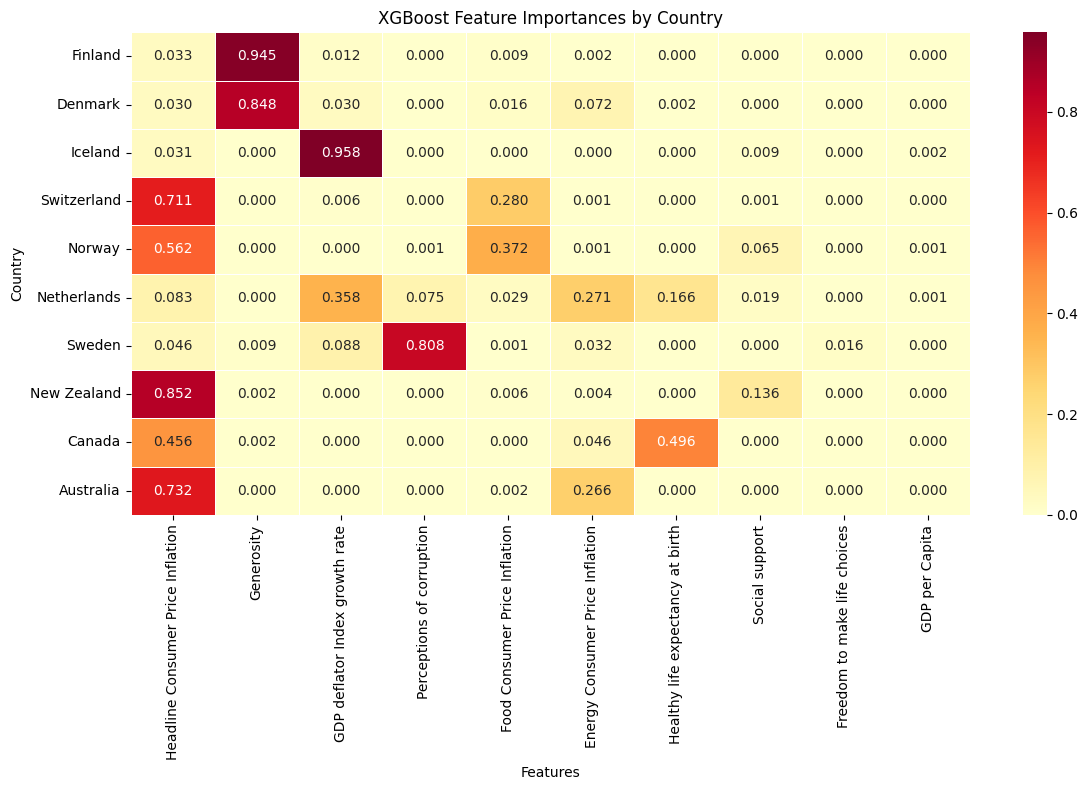

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert feature importance dictionary to DataFrame
df_xgb_importance = pd.DataFrame(xgb_country_feature_importances).T

# Optional: Reorder features by average importance (most important left)
df_xgb_importance = df_xgb_importance.reindex(
    df_xgb_importance.mean().sort_values(ascending=False).index,
    axis=1
)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_xgb_importance, annot=True, cmap='YlOrRd', linewidths=0.5, fmt=".3f")
plt.title("XGBoost Feature Importances by Country")
plt.xlabel("Features")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


# 7. Comparison table of 3 trained model evaluation of metrics

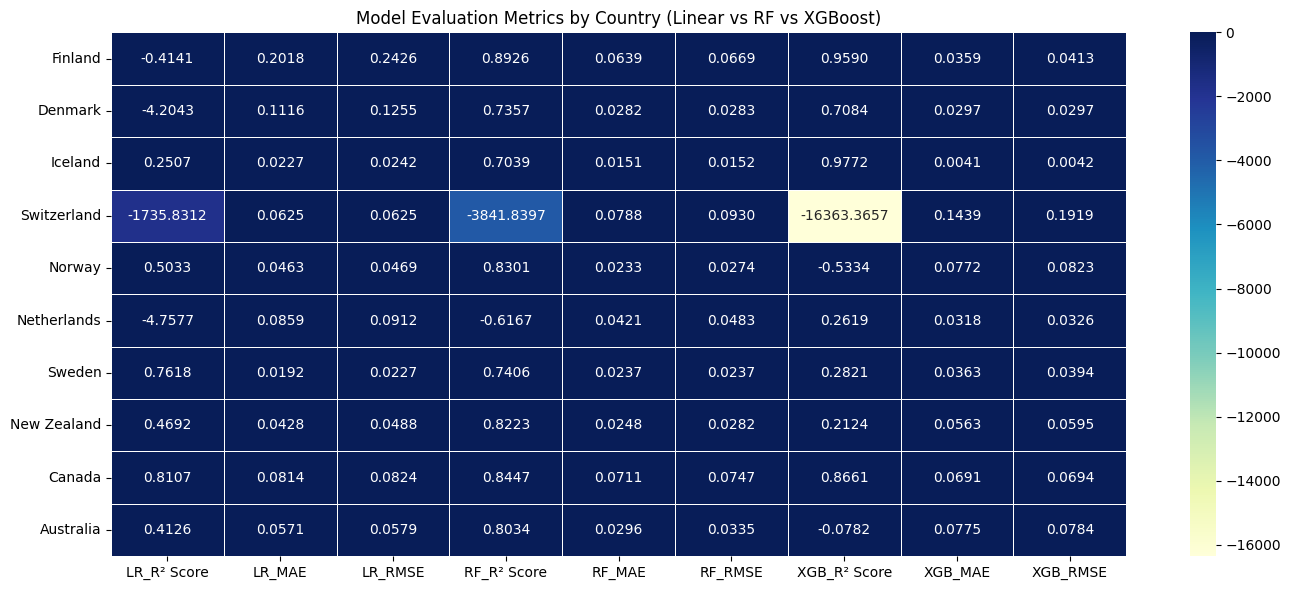

In [24]:
# Make sure these three variables exist: lr_model_scores, rf_model_scores, xgb_model_scores
# Each should be a dictionary where keys are country names and values are dictionaries with R², MAE, RMSE

# Step 1: Convert model score dictionaries to DataFrames
df_lr_scores = pd.DataFrame(lr_model_scores).T.add_prefix('LR_')
df_rf_scores = pd.DataFrame(rf_model_scores).T.add_prefix('RF_')
df_xgb_scores = pd.DataFrame(xgb_model_scores).T.add_prefix('XGB_')

# Step 2: Merge all three DataFrames using country as index
df_combined_scores = df_lr_scores.join(df_rf_scores).join(df_xgb_scores)

# Step 3: Round for readability
df_combined_scores_rounded = df_combined_scores.round(4)

# Step 4: Display in notebook
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.heatmap(df_combined_scores_rounded, annot=True, cmap="YlGnBu", fmt=".4f", linewidths=0.5)
plt.title("Model Evaluation Metrics by Country (Linear vs RF vs XGBoost)")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Optional: Export to CSV
df_combined_scores_rounded.to_csv("model_comparison_scores.csv")
